<font size = "3">

**(Q1)** Below is the `build_parse_tree` function we saw in class, along with some  example calls to the function.

In [1]:
from assign4_utils import Stack, BinaryTree

def build_parse_tree(fp_expr):
    fp_list = fp_expr.split()
    p_stack = Stack()
    expr_tree = BinaryTree("")
    # p_stack.push(expr_tree)
    p_stack.push(None) # I think this is more clear
    current_tree = expr_tree

    for i in fp_list:
        if i == "(":
            current_tree.insert_left("")
            p_stack.push(current_tree)
            current_tree = current_tree.left_child
        elif i in ["+", "-", "*", "/"]:
            current_tree.key = i
            current_tree.insert_right("")
            p_stack.push(current_tree)
            current_tree = current_tree.right_child
        elif i.isdigit():
              current_tree.key = int(i)
              parent = p_stack.pop()
              current_tree = parent
        elif i == ")":
              current_tree = p_stack.pop()
        else:
              raise ValueError(f"Unknown operator '{i}'")

    return expr_tree

pt = build_parse_tree("( 10 + 3 )")
pt.postorder()


10
3
+


In [2]:
expr = "( ( ( 4 * 3 ) + ( 5 * 2 ) ) / 2 )"
pt = build_parse_tree(expr)
pt.postorder()

4
3
*
5
2
*
+
2
/


<font size = "3">

Modify the function to define `build_parse_tree_v2` which does not require the outermost parentheses in an expression.

In [3]:
def build_parse_tree_v2(fp_expr):
    fp_list = fp_expr.split()

    # Allows us to handle things like
    # "( ( ( 10 + 3 ) ) )" efficiently
    trim_str = True
    while trim_str:
        if fp_list[0] == "(" and fp_list[-1] == ")":
            fp_list.pop()
            fp_list.pop(0)
        else:
            trim_str = False
    
    p_stack = Stack()
    expr_tree = BinaryTree("")

    expr_tree.insert_left("")
    p_stack.push(expr_tree)
    current_tree = expr_tree.left_child

    for i in fp_list:
        if i == "(":
            current_tree.insert_left("")
            p_stack.push(current_tree)
            current_tree = current_tree.left_child
        elif i in ["+", "-", "*", "/"]:
            current_tree.key = i
            current_tree.insert_right("")
            p_stack.push(current_tree)
            current_tree = current_tree.right_child
        elif i.isdigit():
              current_tree.key = int(i)
              parent = p_stack.pop()
              current_tree = parent
        elif i == ")":
              current_tree = p_stack.pop()
        else:
              raise ValueError(f"Unknown operator '{i}'")

    return expr_tree



In [4]:
# This should return a tree with 
# the following values in a postorder traversal: 10 3 +
pt = build_parse_tree_v2("10 + 3")
pt.postorder()
print()
print("key:", pt.key)
print("left_child:", pt.left_child)
print("right_child:", pt.right_child)

10
3
+

key: +
left_child: BinaryTree with root value 10
right_child: BinaryTree with root value 3


In [5]:
pt = build_parse_tree_v2("( 10 + 3 )")
pt.postorder()
print()
print("key:", pt.key)
print("left_child:", pt.left_child)
print("right_child:", pt.right_child)

10
3
+

key: +
left_child: BinaryTree with root value 10
right_child: BinaryTree with root value 3


In [6]:
pt = build_parse_tree_v2("( ( 10 + 3 ) )")
pt.postorder()
print()
print("key:", pt.key)
print("left_child:", pt.left_child)
print("right_child:", pt.right_child)

10
3
+

key: +
left_child: BinaryTree with root value 10
right_child: BinaryTree with root value 3


In [7]:
# This should return a tree with 
# the following values in a postorder traversal: 4 3 * 5 2 * + 2 /
expr = "( ( 4 * 3 ) + ( 5 * 2 ) ) / 2"
pt = build_parse_tree_v2(expr)
pt.postorder()
print()
print("key:", pt.key)
print("left_child:", pt.left_child)
print("right_child:", pt.right_child)

4
3
*
5
2
*
+
2
/

key: /
left_child: BinaryTree with root value +
right_child: BinaryTree with root value 2


<font size = "3">

**(Q2)** We can "invert" the procedure that converts a string into a parse tree using the `print_exp` function:

In [8]:
def print_exp(tree):
    result = ""
    if tree:
        result = "(" + print_exp(tree.left_child)
        result = result + str(tree.key)
        result = result + print_exp(tree.right_child) + ")"
    return result

pt = build_parse_tree("( ( 10 + 5 ) * 3 )")

pt_str = print_exp(pt)

print(pt_str)

(((10)+(5))*(3))


<font size = "3">

Modify the function so that it does not include the extra parentheses around each individual number.

I.e. the modified function would return the string `((10 + 5)*3)`

In [9]:
def print_exp_modified(tree):
    result = ""
    if tree:
        if tree.left_child and tree.right_child:
            result = "(" + print_exp_modified(tree.left_child)
            result = result + str(tree.key)
            result = result + print_exp_modified(tree.right_child) + ")"
        else:
            result = str(tree.key)
    return result

pt = build_parse_tree("( ( 10 + 5 ) * 3 )")

pt_str = print_exp_modified(pt)

print(pt_str)

((10+5)*3)


<font size = "3">

**(Q3)** Create a binary heap class with a limited heap size. In other words, the heap only keeps track of the $m$
most important items. If the heap grows in size to more than $m$ items the least important item is dropped (while maintaining the binary heap structure).

Continue to use the *min heap* framework, where the least important item has the largest key value.

In [10]:
class BinaryHeap:
    # New additions:
    # 1. initialized with _max_size property
    # 2. find_max_key(self)
    # 3. if statement inside insert(self, item)
    # 4. while loop inside heapify

    def __init__(self, max_size):
        self._heap = []
        self._max_size = max_size

    def _perc_up(self, i):
        while (i - 1) // 2 >= 0:
            p = (i - 1) // 2
            if self._heap[i] < self._heap[p]:
                self._heap[i],self._heap[p] = (
                    self._heap[p], self._heap[i]
                )
            else:
                break
            i = p

    def insert(self, item):
        self._heap.append(item)
        self._perc_up(len(self._heap) - 1)
        if len(self._heap) > self._max_size:
            M = self.find_max_key()
            self._heap[M], self._heap[-1] = self._heap[-1], self._heap[M]
            self._perc_up(M)
            self._heap.pop()


    def find_max_key(self):
        leaf_start = len(self._heap) // 2
        max_elem = self._heap[0]
        max_ind = leaf_start
        for k in range(leaf_start+1, len(self._heap)):
            if self._heap[k] > max_elem:
                max_ind = k
                max_elem = self._heap[k]
        return max_ind


    def _get_min_child(self, i):
        if 2 * i + 2 > len(self._heap) - 1: # no right child
            return 2 * i + 1
        if self._heap[2 * i + 1] < self._heap[2 * i + 2]:
            # tie -> take right_child
            return 2 * i + 1
        return 2 * i + 2
    
    def _perc_down(self, i):
        while 2 * i + 1 < len(self._heap):
            sm_child = self._get_min_child(i)
            if self._heap[i] > self._heap[sm_child]:
                self._heap[i], self._heap[sm_child] = (
                    self._heap[sm_child], self._heap[i]
                )
            else:
                break
            i = sm_child

    def delete(self):
        # swap, pop, percolate down
        self._heap[0], self._heap[-1] = self._heap[-1], self._heap[0]
        result = self._heap.pop()
        self._perc_down(0)
        return result

    def heapify(self, not_a_heap):
        # make a copy of the input list
        self._heap = not_a_heap[:]
        # left-most node in second-lowest level
        i = len(self._heap) // 2 - 1
        while i >= 0:
            self._perc_down(i)
            i = i - 1

        while len(self._heap) > self._max_size:
            M = self.find_max_key()
            self._heap[M], self._heap[-1] = self._heap[-1], self._heap[M]
            self._perc_up(M)
            self._heap.pop()
    
    def is_empty(self):
        return not bool(self._heap)

    def __len__(self):
        return len(self._heap)

    def __str__(self):
        return str(self._heap)

<font size = "3">

**(Q4)** Using the `heapify` function, write a sorting function that can sort a sorted list in $\mathcal{O}(n\log n)$ time.

Keep the following in mind as you design your algorithm:

- The `heapify` method is an $\mathcal{O}(n)$ operation.

- "Percolating" up or down is an $\mathcal{O}(\log n)$ operation.

- Swapping two items in a list is an $\mathcal{O}(1)$ operation.

- Popping from the end of a list is an $\mathcal{O}(1)$ operation.

- Popping from the beginning of a list is an $\mathcal{O}(n)$ operation.

You might find it convenient to write an independent `heapify` function instead of calling the method from a `BinaryHeap` object.

In [11]:
def get_min_child(lst, i):
    if 2 * i + 2 > len(lst) - 1: # no right child
        return 2 * i + 1
    if lst[2 * i + 1] < lst[2 * i + 2]:
        # tie -> take right_child
        return 2 * i + 1
    return 2 * i + 2

def perc_down(lst, i):
    while 2 * i + 1 < len(lst):
        sm_child = get_min_child(lst, i)
        if lst[i] > lst[sm_child]:
            lst[i], lst[sm_child] = (
                lst[sm_child], lst[i]
            )
        else:
            break
        i = sm_child

def heapify(lst):
    i = len(lst) // 2 - 1
    while i >= 0:
        perc_down(lst,i)
        i = i - 1

def heapsort(lst):
    n = len(lst)
    lst_sorted = []
    heapify(lst) # O(n)
    for k in range(n-1):
        lst[0], lst[-1] = lst[-1], lst[0] # O(1)
        lst_sorted.append(lst.pop()) # O(1) pop, O(1) append
        perc_down(lst, 0) # O(log n)
    lst_sorted.append(lst.pop()) # O(1) pop, O(1) append

    # Cost: O(n) + (n-1) * [O(1) + O(1) + O(1) + O(log n)] + O(1) + O(1)
    # = O(n) + (n-1) * O(log n) + O(1)
    # = O(n) + (n-1) * O(log n)
    # = O(n) + O(n log n)
    # = O(n log n)
    return lst_sorted

<font size = "3">

**(Q5)** Empirically verify that the function you wrote for Question 4 has $\mathcal{O}(n \log n)$ cost by testing it on lists of integers of different sizes.

n =  8 done
n =  16 done
n =  32 done
n =  64 done
n =  128 done
n =  256 done


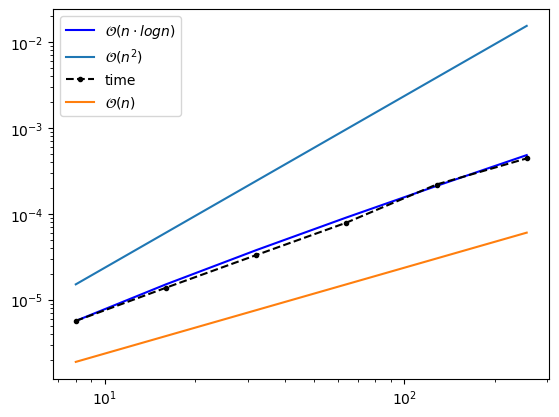

In [18]:
from timeit import default_timer
import numpy as np
import random
import matplotlib.pyplot as plt 


k_vals = np.array([3, 4, 5, 6, 7, 8])
n_vals = 2**k_vals 
n_times = np.zeros(n_vals.shape)

num_repeats = 25
for i, n in enumerate(n_vals):
    for _ in range(num_repeats):
        random.seed(3200)
        lst = random.choices(range(1001), k=n)
        start = default_timer()
        heapsort(lst)
        stop = default_timer()
        n_times[i] += stop - start 
        
    n_times[i] /= num_repeats
    print("n = ", n, "done")



C = n_times[0] / (n_vals[0] * np.log2(n_vals[0]))
plt.loglog(n_vals, C*n_vals*np.log2(n_vals), 'b', label = '$\mathcal{O}(n\cdot  log n)$')
plt.loglog(n_vals, C*n_vals**2, label = '$\mathcal{O}(n^2)$')
plt.loglog(n_vals, n_times,'k.--',label = 'time')
plt.loglog(n_vals, C*n_vals, label = '$\mathcal{O}(n)$')
plt.legend()
plt.show()